# Object Classification with PyTorch: Why CNNs Outperform Simple MLPs on Images

In the previous MNIST notebook, a Multilayer Perceptron (MLP) performed well because handwritten digits are relatively simple and centered.  
In this notebook, we move to **CIFAR-10**, a more challenging object classification dataset, to demonstrate an important limitation of a simple MLP:

> An MLP flattens the image into a vector and loses its explicit spatial structure, while a Convolutional Neural Network (CNN) processes local visual patterns such as edges, textures, and shapes.

We will train and compare:

1. A **simple MLP** that receives flattened RGB pixels.
2. A **small CNN** that preserves spatial structure through convolutional layers.

At the end, we will compare test accuracy, classification reports, confusion matrices, and incorrectly classified examples.

## Learning objectives

By the end of this notebook, you should be able to:

- Load and inspect CIFAR-10 images using `torchvision`.
- Explain why flattening an image is a limitation for object classification.
- Implement an MLP and a CNN in PyTorch.
- Train both models under comparable conditions.
- Evaluate both models using a classification report and confusion matrix.
- Interpret why a CNN generally performs better on natural images.

**Important interpretation:** this experiment demonstrates the architectural advantage of convolution for this setup. Exact metric values vary with random seed, number of epochs, hardware, and hyperparameters.

## 1. Imports and environment setup

The code below imports PyTorch, `torchvision` for CIFAR-10, and scikit-learn for final evaluation metrics.

If your environment is missing a package, uncomment and execute the installation line first.

In [1]:
# Uncomment only when running in an environment that does not have the packages installed.
# %pip install torch torchvision scikit-learn pandas matplotlib

from dataclasses import dataclass
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, utils

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

try:
    from IPython.display import display
except ImportError:
    display = print

## 2. Reproducibility and device

Training on a GPU is substantially faster than training on a CPU.  
The notebook automatically selects CUDA when it is available.

In [2]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds to make data splits and initial weights reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Answer to the Ultimate Question of Life, the Universe, and Everything
SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Configuration

CIFAR-10 contains color images with shape `3 × 32 × 32`, so each flattened image has `3,072` input values.

The notebook uses the same data, loss function, optimizer family, and training duration for both models. This keeps the comparison focused on the difference between:

- **MLP:** fully connected layers after flattening the image.
- **CNN:** convolutional layers that preserve spatial relationships.

For a fast CPU demonstration, set `QUICK_DEMO = True`. For a better comparison, use the full dataset and preferably a GPU.

In [3]:
# Dataset configuration
DATA_ROOT = Path("./data")
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)
IMAGE_CHANNELS = 3
IMAGE_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)

# Training configuration
BATCH_SIZE = 128
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VALIDATION_SPLIT = 0.10
NUM_WORKERS = 0  # Safe default for Jupyter notebooks and Windows.
PIN_MEMORY = DEVICE.type == "cuda"

# Set this to True for a faster but less conclusive demonstration.
QUICK_DEMO = False
QUICK_TRAIN_SAMPLES = 12_000
QUICK_VALIDATION_SAMPLES = 2_000
QUICK_TEST_SAMPLES = 3_000

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## 4. Loading CIFAR-10

Unlike MNIST, CIFAR-10 contains small **RGB object images**, including airplanes, cars, animals, ships, and trucks.  
We normalize the three color channels using common CIFAR-10 statistics. Both models receive exactly the same normalized input images.

No data augmentation is used here, so that the architecture comparison stays simple and easy to interpret.

In [4]:
# Normalization values commonly used for CIFAR-10 experiments.
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ]
)


def get_dataloaders():
    """Download CIFAR-10, create a reproducible train/validation split, and return DataLoaders."""
    full_train_dataset = datasets.CIFAR10(
        root=DATA_ROOT,
        train=True,
        download=True,
        transform=transform,
    )
    test_dataset = datasets.CIFAR10(
        root=DATA_ROOT,
        train=False,
        download=True,
        transform=transform,
    )

    validation_size = int(len(full_train_dataset) * VALIDATION_SPLIT)
    training_size = len(full_train_dataset) - validation_size

    train_dataset, validation_dataset = random_split(
        full_train_dataset,
        [training_size, validation_size],
        generator=torch.Generator().manual_seed(SEED),
    )

    if QUICK_DEMO:
        train_dataset = Subset(
            train_dataset, range(min(QUICK_TRAIN_SAMPLES, len(train_dataset)))
        )
        validation_dataset = Subset(
            validation_dataset,
            range(min(QUICK_VALIDATION_SAMPLES, len(validation_dataset))),
        )
        test_dataset = Subset(
            test_dataset, range(min(QUICK_TEST_SAMPLES, len(test_dataset)))
        )

    loader_options = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
    validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

    return train_loader, validation_loader, test_loader


train_loader, validation_loader, test_loader = get_dataloaders()

print(f"Training samples:   {len(train_loader.dataset):,}")
print(f"Validation samples: {len(validation_loader.dataset):,}")
print(f"Test samples:       {len(test_loader.dataset):,}")

100%|████████████████████████████████████████████████████████████████████████████████████████████| 170498071/170498071 [01:46<00:00, 1606857.06it/s]


Extracting data/cifar-10-python.tar.gz to data
Files already downloaded and verified
Training samples:   45,000
Validation samples: 5,000
Test samples:       10,000


## 5. Inspecting the object images

CIFAR-10 is visually harder than MNIST:

- Images contain three color channels instead of one grayscale channel.
- Objects can appear with different textures, backgrounds, and poses.
- Similar classes, such as cats and dogs or automobiles and trucks, can be difficult to distinguish.

The following cell displays a batch of training images after undoing normalization.

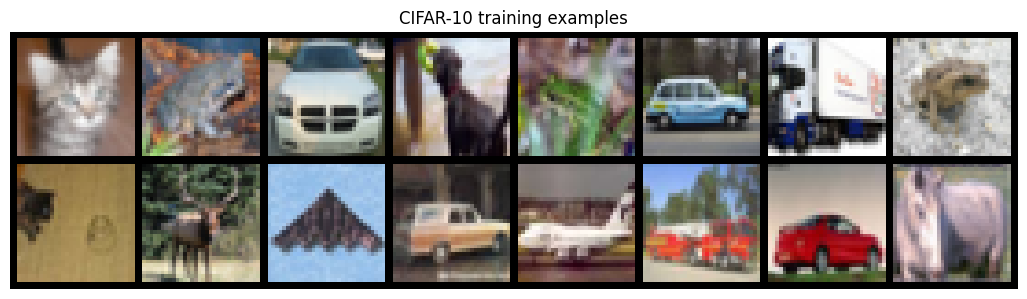

Labels:
cat | frog | automobile | dog | frog | automobile | truck | frog | cat | deer | airplane | automobile | airplane | truck | automobile | horse


In [5]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    """Undo CIFAR-10 normalization so images can be displayed correctly."""
    mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
    return torch.clamp(images.cpu() * std + mean, 0, 1)


def show_training_examples(loader: DataLoader, n_images: int = 16) -> None:
    """Display example images from a DataLoader in a single visual grid."""
    images, labels = next(iter(loader))
    images = denormalize(images[:n_images])
    labels = labels[:n_images]

    image_grid = utils.make_grid(images, nrow=8, padding=2)

    plt.figure(figsize=(13, 4))
    plt.imshow(image_grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("CIFAR-10 training examples")
    plt.show()

    print("Labels:")
    print(" | ".join(CLASS_NAMES[label.item()] for label in labels))


show_training_examples(train_loader)

## 6. Why may an MLP struggle with natural images?

An MLP expects a vector. Therefore, an RGB image of shape `3 × 32 × 32` is flattened into a vector with `3,072` entries:

```text
image tensor:   [channels, height, width] = [3, 32, 32]
flattened MLP input:                     = [3072]
```

After flattening, the network does not explicitly know that nearby pixels form local structures. It must learn from scratch that adjacent values can represent edges, textures, and object parts.

A CNN uses small filters that move across the image. This gives it an inductive bias for:

- local patterns,
- spatial structure,
- reusable features appearing in different image regions.

The next cell visually contrasts a natural image with its flattened input representation.

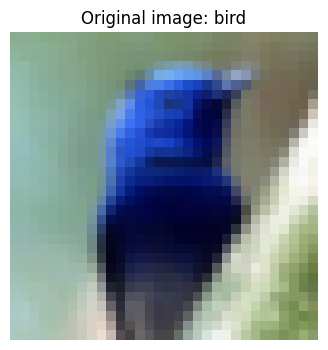

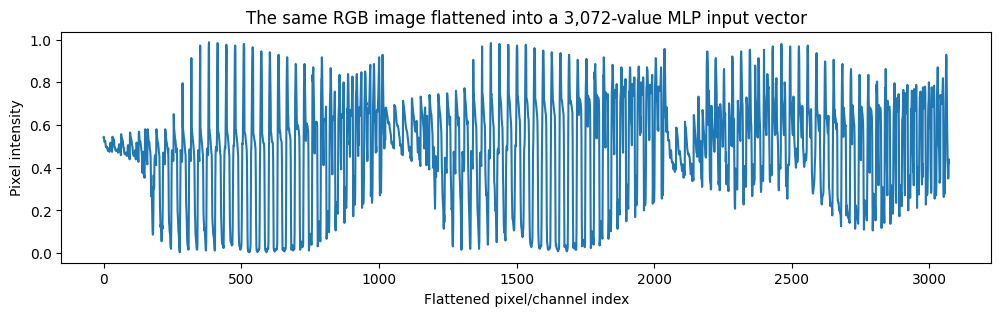

In [6]:
images, labels = next(iter(train_loader))
example_image = denormalize(images[:1])[0]
flattened_image = example_image.flatten()

plt.figure(figsize=(4, 4))
plt.imshow(example_image.permute(1, 2, 0))
plt.title(f"Original image: {CLASS_NAMES[labels[0].item()]}")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(flattened_image.numpy())
plt.title("The same RGB image flattened into a 3,072-value MLP input vector")
plt.xlabel("Flattened pixel/channel index")
plt.ylabel("Pixel intensity")
plt.show()

## 7. Model definitions

### Model A: Simple MLP

The MLP flattens each image and then uses dense layers. Every hidden unit has its own weights for the flattened input positions.

### Model B: Small CNN

The CNN uses convolution and max pooling before the final classifier. Convolutional filters learn local visual patterns and reuse those filters throughout the image.

Notice that the CNN can have fewer parameters than the MLP while still being better suited to image structure.

In [7]:
class MLPClassifier(nn.Module):
    """A simple fully connected classifier that discards explicit spatial structure."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        flattened_size = IMAGE_CHANNELS * IMAGE_SIZE * IMAGE_SIZE

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 512),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The output contains logits. CrossEntropyLoss applies the required
        # probability transformation internally.
        return self.classifier(x)


class CNNClassifier(nn.Module):
    """A compact CNN that learns spatially local features before classification."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            # Input shape: [batch, 3, 32, 32]
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # -> [batch, 32, 32, 32]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                   # -> [batch, 32, 16, 16]

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # -> [batch, 64, 16, 16]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                   # -> [batch, 64, 8, 8]

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # -> [batch, 128, 8, 8]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                   # -> [batch, 128, 4, 4]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


def count_trainable_parameters(model: nn.Module) -> int:
    """Count parameters updated during gradient descent."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


mlp_model = MLPClassifier().to(DEVICE)
cnn_model = CNNClassifier().to(DEVICE)

parameter_summary = pd.DataFrame(
    [
        {
            "Model": "MLP",
            "Trainable parameters": count_trainable_parameters(mlp_model),
            "Spatial processing": "No — image is flattened",
        },
        {
            "Model": "CNN",
            "Trainable parameters": count_trainable_parameters(cnn_model),
            "Spatial processing": "Yes — convolutional filters",
        },
    ]
)

display(parameter_summary.style.format({"Trainable parameters": "{:,}"}))

sample_images, _ = next(iter(train_loader))
sample_images = sample_images[:4].to(DEVICE)

with torch.no_grad():
    print("MLP output shape:", mlp_model(sample_images).shape)
    print("CNN output shape:", cnn_model(sample_images).shape)

,Model,Trainable parameters,Spatial processing
0,MLP,"1,707,274",No — image is flattened
1,CNN,"356,810",Yes — convolutional filters


MLP output shape: torch.Size([4, 10])
CNN output shape: torch.Size([4, 10])


## 8. Training and evaluation utilities

Both networks are trained using:

- `CrossEntropyLoss`, which expects model logits and target class indices.
- Adam optimizer.
- The same number of epochs and validation procedure.
- A checkpoint containing the weights with the best validation accuracy.

We record both loss and accuracy so that we can compare learning behavior.

In [8]:
@dataclass
class EpochResult:
    loss: float
    accuracy: float


def run_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> EpochResult:
    """Run one training or evaluation epoch and return mean loss and accuracy."""
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

    return EpochResult(
        loss=total_loss / total_samples,
        accuracy=total_correct / total_samples,
    )


def load_weights(model: nn.Module, checkpoint_path: Path) -> None:
    """Load weights while remaining compatible with multiple PyTorch versions."""
    try:
        state_dict = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)

    model.load_state_dict(state_dict)


def train_model(model: nn.Module, model_name: str) -> pd.DataFrame:
    """Train one model, save its best validation weights, and return its history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    checkpoint_path = CHECKPOINT_DIR / f"cifar10_{model_name.lower()}_best_weights.pth"
    best_validation_accuracy = 0.0
    history = []

    starting_time = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        train_result = run_epoch(model, train_loader, criterion, optimizer)
        validation_result = run_epoch(model, validation_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_result.loss,
                "validation_loss": validation_result.loss,
                "train_accuracy": train_result.accuracy,
                "validation_accuracy": validation_result.accuracy,
            }
        )

        if validation_result.accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_result.accuracy
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"{model_name:>3} | Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Train loss: {train_result.loss:.4f} | "
            f"Train acc: {train_result.accuracy:.2%} | "
            f"Val acc: {validation_result.accuracy:.2%}"
        )

    elapsed_minutes = (time.time() - starting_time) / 60
    load_weights(model, checkpoint_path)

    print(
        f"\n{model_name} training finished in {elapsed_minutes:.2f} minutes. "
        f"Best validation accuracy: {best_validation_accuracy:.2%}"
    )

    return pd.DataFrame(history)

## 9. Train the MLP

Because the MLP receives flattened pixels, it must infer object structure using only dense connections.  
Its results provide the baseline for this comparison.

In [9]:
set_seed(SEED)
mlp_model = MLPClassifier().to(DEVICE)
mlp_history = train_model(mlp_model, model_name="MLP")

MLP | Epoch 01/10 | Train loss: 1.7728 | Train acc: 36.96% | Val acc: 44.20%
MLP | Epoch 02/10 | Train loss: 1.6209 | Train acc: 42.38% | Val acc: 45.78%
MLP | Epoch 03/10 | Train loss: 1.5595 | Train acc: 44.58% | Val acc: 47.14%
MLP | Epoch 04/10 | Train loss: 1.5206 | Train acc: 46.27% | Val acc: 49.28%
MLP | Epoch 05/10 | Train loss: 1.4773 | Train acc: 47.93% | Val acc: 49.90%
MLP | Epoch 06/10 | Train loss: 1.4501 | Train acc: 48.70% | Val acc: 49.06%
MLP | Epoch 07/10 | Train loss: 1.4237 | Train acc: 49.44% | Val acc: 50.10%
MLP | Epoch 08/10 | Train loss: 1.4093 | Train acc: 50.42% | Val acc: 50.56%
MLP | Epoch 09/10 | Train loss: 1.3877 | Train acc: 50.94% | Val acc: 50.62%
MLP | Epoch 10/10 | Train loss: 1.3741 | Train acc: 51.04% | Val acc: 50.58%

MLP training finished in 1.49 minutes. Best validation accuracy: 50.62%


## 10. Train the CNN

The CNN learns spatial features before performing the final classification.  
With CIFAR-10, it is expected to produce better object-classification results than the simple MLP under the same general training setup.

In [10]:
set_seed(SEED)
cnn_model = CNNClassifier().to(DEVICE)
cnn_history = train_model(cnn_model, model_name="CNN")

CNN | Epoch 01/10 | Train loss: 1.5543 | Train acc: 42.98% | Val acc: 53.26%
CNN | Epoch 02/10 | Train loss: 1.1510 | Train acc: 58.86% | Val acc: 64.86%
CNN | Epoch 03/10 | Train loss: 0.9716 | Train acc: 65.64% | Val acc: 68.80%
CNN | Epoch 04/10 | Train loss: 0.8404 | Train acc: 70.53% | Val acc: 71.52%
CNN | Epoch 05/10 | Train loss: 0.7636 | Train acc: 73.16% | Val acc: 73.26%
CNN | Epoch 06/10 | Train loss: 0.6931 | Train acc: 75.58% | Val acc: 74.94%
CNN | Epoch 07/10 | Train loss: 0.6236 | Train acc: 78.15% | Val acc: 75.82%
CNN | Epoch 08/10 | Train loss: 0.5727 | Train acc: 79.90% | Val acc: 75.32%
CNN | Epoch 09/10 | Train loss: 0.5193 | Train acc: 81.53% | Val acc: 75.60%
CNN | Epoch 10/10 | Train loss: 0.4719 | Train acc: 83.19% | Val acc: 76.52%

CNN training finished in 1.61 minutes. Best validation accuracy: 76.52%


## 11. Compare learning curves

These plots show how the models behave during training and validation.  
A higher validation accuracy for the CNN indicates that preserving spatial structure is useful for object classification.

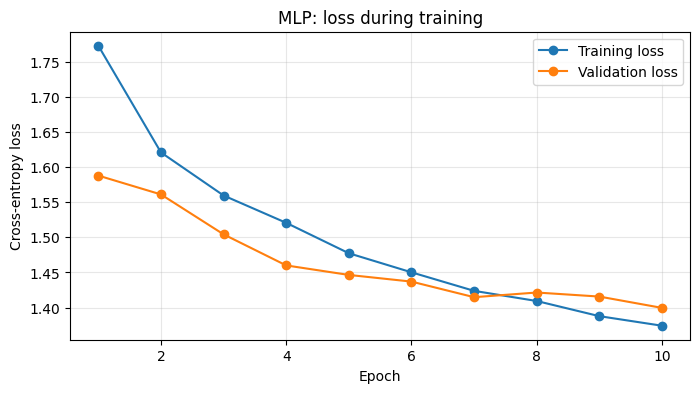

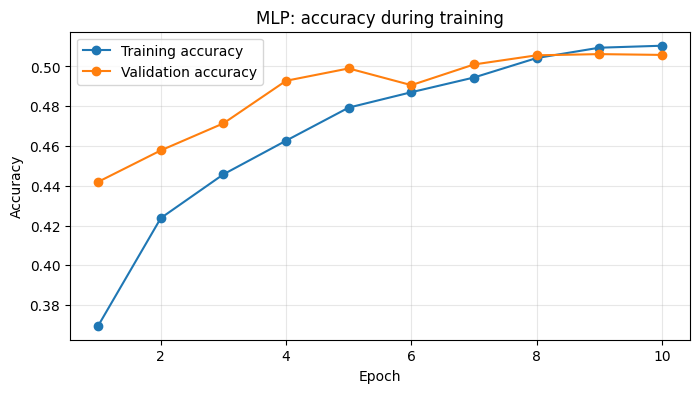

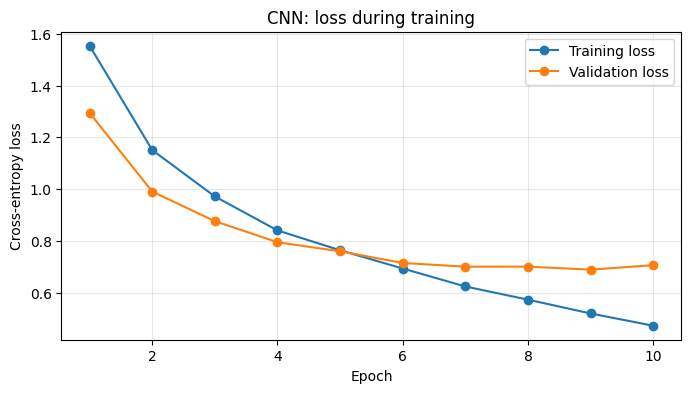

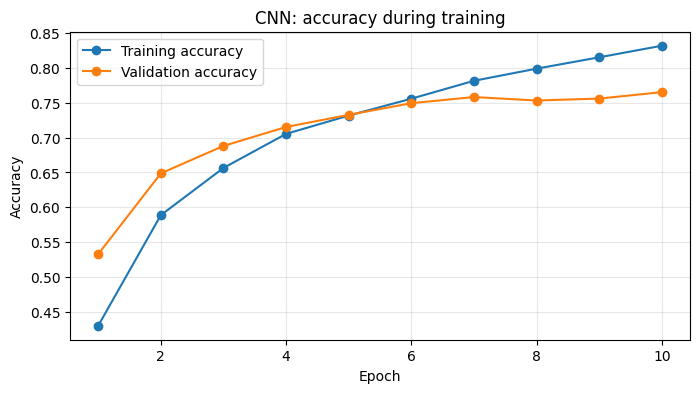

In [11]:
def plot_training_history(history: pd.DataFrame, model_name: str) -> None:
    """Plot loss and accuracy histories in separate figures."""
    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
    plt.plot(history["epoch"], history["validation_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(f"{model_name}: loss during training")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_accuracy"], marker="o", label="Training accuracy")
    plt.plot(history["epoch"], history["validation_accuracy"], marker="o", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name}: accuracy during training")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_training_history(mlp_history, "MLP")
plot_training_history(cnn_history, "CNN")

## 12. Collect test predictions

The test set is kept separate from training and validation.  
It is used only after model selection to estimate how each trained model performs on unseen images.

In [12]:
def predict_dataset(model: nn.Module, data_loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Return true labels and predicted labels for a complete DataLoader."""
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()

            true_labels.extend(labels.numpy())
            predicted_labels.extend(predictions.numpy())

    return np.array(true_labels), np.array(predicted_labels)


y_true, mlp_predictions = predict_dataset(mlp_model, test_loader)
_, cnn_predictions = predict_dataset(cnn_model, test_loader)

## 13. Overall metric comparison

Accuracy is easy to interpret, but it hides performance differences between individual object classes.  
We also calculate balanced accuracy, macro precision, macro recall, and macro F1-score.

In [13]:
def calculate_overall_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> dict:
    """Calculate overall classification metrics for one model."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro precision": precision,
        "Macro recall": recall,
        "Macro F1-score": f1,
        "Trainable parameters": count_trainable_parameters(
            mlp_model if model_name == "MLP" else cnn_model
        ),
    }


metrics_comparison = pd.DataFrame(
    [
        calculate_overall_metrics(y_true, mlp_predictions, "MLP"),
        calculate_overall_metrics(y_true, cnn_predictions, "CNN"),
    ]
)

display(
    metrics_comparison.style.format(
        {
            "Accuracy": "{:.2%}",
            "Balanced accuracy": "{:.2%}",
            "Macro precision": "{:.2%}",
            "Macro recall": "{:.2%}",
            "Macro F1-score": "{:.2%}",
            "Trainable parameters": "{:,}",
        }
    )
)

,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1-score,Trainable parameters
0,MLP,50.68%,50.68%,50.96%,50.68%,50.65%,"1,707,274"
1,CNN,75.82%,75.82%,76.04%,75.82%,75.59%,"356,810"


## 14. Classification reports

A classification report provides precision, recall, and F1-score for every class.

Use it to investigate questions such as:

- Does the MLP confuse visually related animal classes?
- Does the CNN improve performance consistently, or only for particular classes?
- Which object categories remain difficult even for the CNN?

In [14]:
def show_classification_report(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> pd.DataFrame:
    """Print and return a formatted per-class classification report."""
    print(f"{model_name} classification report")
    print("-" * (len(model_name) + 22))
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()


mlp_report = show_classification_report(y_true, mlp_predictions, "MLP")
cnn_report = show_classification_report(y_true, cnn_predictions, "CNN")

MLP classification report
-------------------------
              precision    recall  f1-score   support

    airplane     0.5787    0.5370    0.5571      1000
  automobile     0.6479    0.6110    0.6289      1000
        bird     0.3794    0.3950    0.3871      1000
         cat     0.3513    0.3130    0.3310      1000
        deer     0.4140    0.4550    0.4335      1000
         dog     0.4217    0.4120    0.4168      1000
        frog     0.4976    0.6110    0.5485      1000
       horse     0.6402    0.5160    0.5714      1000
        ship     0.6037    0.6580    0.6297      1000
       truck     0.5617    0.5600    0.5608      1000

    accuracy                         0.5068     10000
   macro avg     0.5096    0.5068    0.5065     10000
weighted avg     0.5096    0.5068    0.5065     10000

CNN classification report
-------------------------
              precision    recall  f1-score   support

    airplane     0.7928    0.7960    0.7944      1000
  automobile     0.8662    0

### Per-class F1-score comparison

This table makes it easier to compare how the two architectures perform on each object category.

In [15]:
per_class_f1_comparison = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "MLP F1-score": [mlp_report.loc[class_name, "f1-score"] for class_name in CLASS_NAMES],
        "CNN F1-score": [cnn_report.loc[class_name, "f1-score"] for class_name in CLASS_NAMES],
    }
)

per_class_f1_comparison["CNN improvement"] = (
    per_class_f1_comparison["CNN F1-score"] - per_class_f1_comparison["MLP F1-score"]
)

display(
    per_class_f1_comparison.style.format(
        {
            "MLP F1-score": "{:.3f}",
            "CNN F1-score": "{:.3f}",
            "CNN improvement": "{:+.3f}",
        }
    )
)

,Class,MLP F1-score,CNN F1-score,CNN improvement
0,airplane,0.557,0.794,+0.237
1,automobile,0.629,0.857,+0.228
2,bird,0.387,0.657,+0.270
3,cat,0.331,0.589,+0.257
4,deer,0.434,0.721,+0.287
5,dog,0.417,0.653,+0.236
6,frog,0.548,0.811,+0.262
7,horse,0.571,0.797,+0.225
8,ship,0.630,0.854,+0.224
9,truck,0.561,0.826,+0.266


## 15. Confusion matrices

A confusion matrix shows which classes are confused with each other.  
For example, visually similar animals may be harder to distinguish than objects with distinctive shapes.

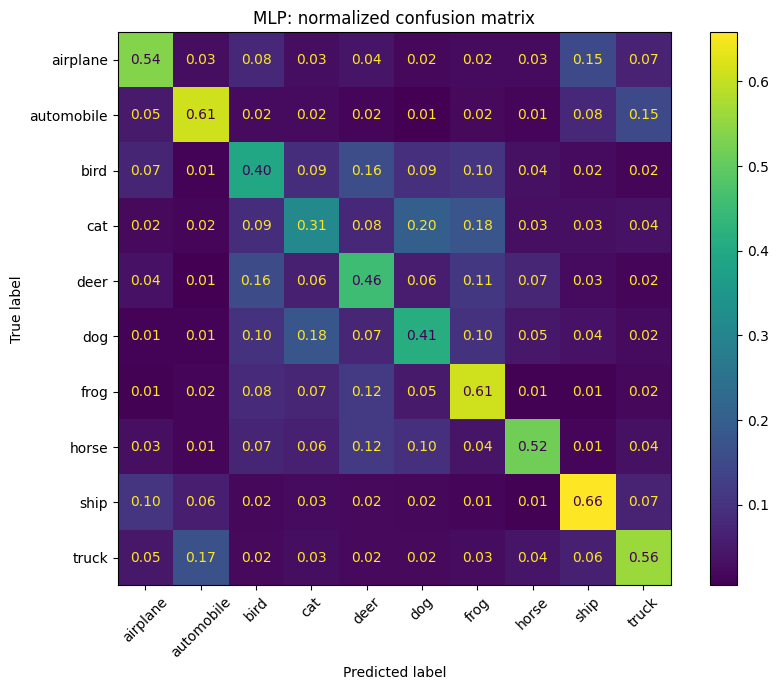

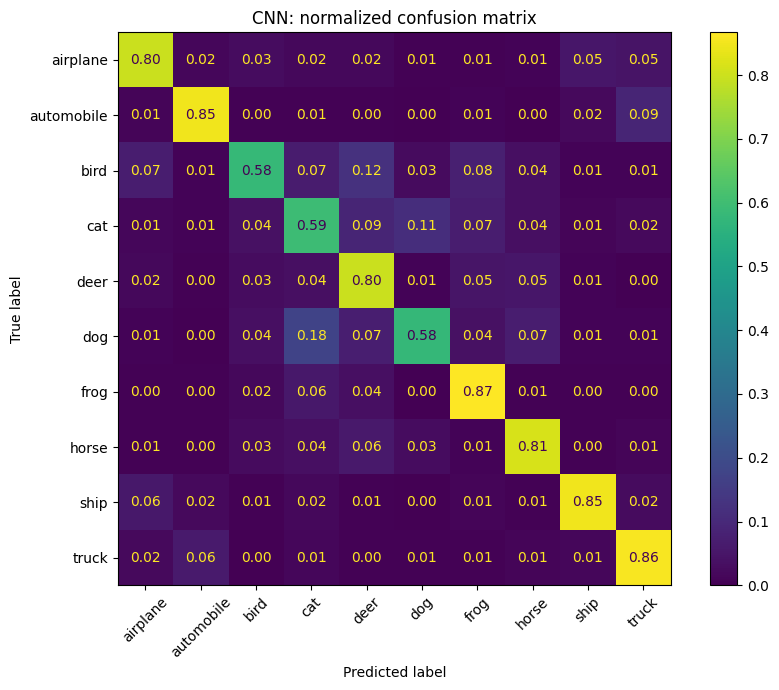

In [16]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> None:
    """Display a normalized confusion matrix for one model."""
    display_object = ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=CLASS_NAMES,
        normalize="true",
        values_format=".2f",
        xticks_rotation=45,
    )
    display_object.ax_.set_title(f"{model_name}: normalized confusion matrix")
    display_object.figure_.set_size_inches(9, 7)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_true, mlp_predictions, "MLP")
plot_confusion_matrix(y_true, cnn_predictions, "CNN")

## 16. Inspecting mistakes

Aggregate metrics are important, but individual mistakes help us understand the challenge.  
The next function displays images a model classified incorrectly, together with true and predicted labels.

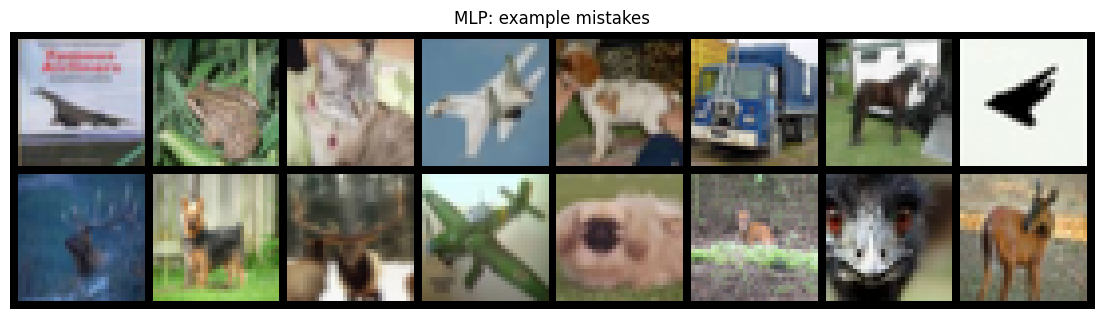

Labels by image position, from left to right:
01. T:airplane / P:ship
02. T:frog / P:deer
03. T:cat / P:deer
04. T:airplane / P:ship
05. T:dog / P:cat
06. T:truck / P:automobile
07. T:horse / P:deer
08. T:airplane / P:bird
09. T:deer / P:bird
10. T:dog / P:deer
11. T:deer / P:cat
12. T:airplane / P:bird
13. T:dog / P:deer
14. T:deer / P:ship
15. T:bird / P:automobile
16. T:deer / P:horse


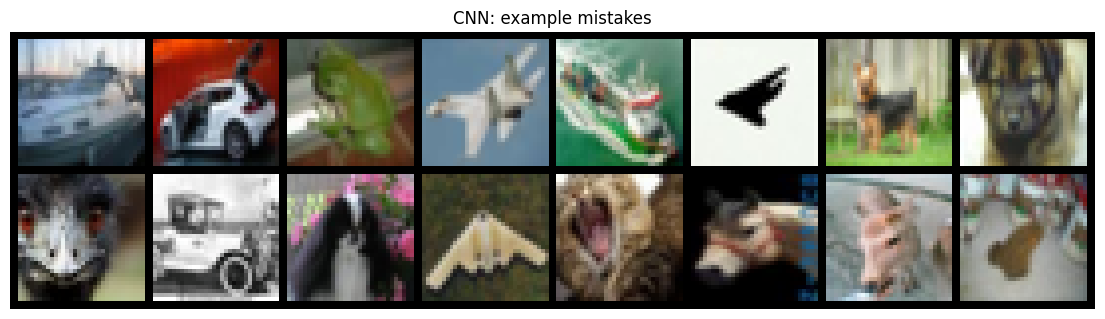

Labels by image position, from left to right:
01. T:ship / P:airplane
02. T:automobile / P:truck
03. T:frog / P:bird
04. T:airplane / P:deer
05. T:ship / P:frog
06. T:airplane / P:bird
07. T:dog / P:deer
08. T:dog / P:cat
09. T:bird / P:truck
10. T:automobile / P:truck
11. T:dog / P:horse
12. T:airplane / P:frog
13. T:cat / P:frog
14. T:horse / P:dog
15. T:deer / P:cat
16. T:frog / P:cat


In [17]:
def show_misclassified_examples(
    model: nn.Module,
    data_loader: DataLoader,
    model_name: str,
    max_examples: int = 16,
) -> None:
    """Display incorrectly classified test images in one image grid."""
    model.eval()
    selected_images = []
    selected_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images.to(DEVICE))
            predictions = logits.argmax(dim=1).cpu()

            incorrect_indices = (predictions != labels).nonzero(as_tuple=True)[0]

            for index in incorrect_indices:
                selected_images.append(images[index])
                selected_labels.append(
                    f"T:{CLASS_NAMES[labels[index].item()]} / "
                    f"P:{CLASS_NAMES[predictions[index].item()]}"
                )
                if len(selected_images) >= max_examples:
                    break

            if len(selected_images) >= max_examples:
                break

    image_grid = utils.make_grid(
        denormalize(torch.stack(selected_images)),
        nrow=8,
        padding=2,
    )

    plt.figure(figsize=(14, 5))
    plt.imshow(image_grid.permute(1, 2, 0))
    plt.title(f"{model_name}: example mistakes")
    plt.axis("off")
    plt.show()

    print("Labels by image position, from left to right:")
    for index, text in enumerate(selected_labels, start=1):
        print(f"{index:02d}. {text}")


show_misclassified_examples(mlp_model, test_loader, "MLP")
show_misclassified_examples(cnn_model, test_loader, "CNN")

## 17. Looking inside the CNN: first-layer feature maps

The first convolutional layer produces multiple feature maps from the same input image.  
Each map responds differently to local image information. This illustrates a key difference from the MLP: the CNN builds spatial feature representations before classification.

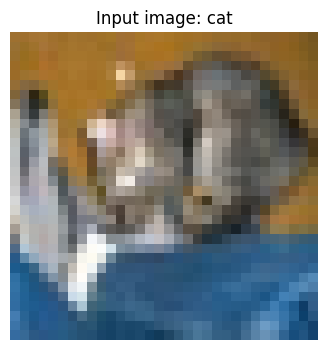

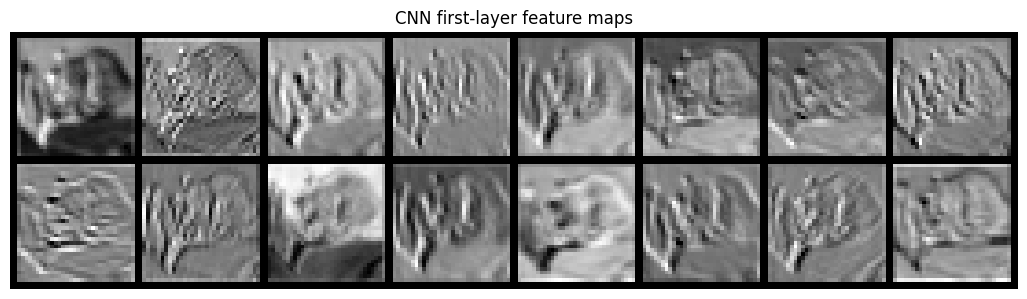

In [18]:
def show_first_layer_feature_maps(
    model: CNNClassifier,
    data_loader: DataLoader,
    n_feature_maps: int = 16,
) -> None:
    """Visualize first-layer CNN activations for one test image."""
    images, labels = next(iter(data_loader))
    image = images[:1].to(DEVICE)

    first_convolution = model.features[0]
    with torch.no_grad():
        feature_maps = first_convolution(image).cpu()
        feature_maps = feature_maps[:, :n_feature_maps]

    normalized_maps = []
    for feature_map in feature_maps[0]:
        minimum = feature_map.min()
        maximum = feature_map.max()
        normalized_maps.append((feature_map - minimum) / (maximum - minimum + 1e-8))

    feature_map_grid = utils.make_grid(
        torch.stack(normalized_maps).unsqueeze(1),
        nrow=8,
        padding=2,
    )

    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize(images[:1])[0].permute(1, 2, 0))
    plt.title(f"Input image: {CLASS_NAMES[labels[0].item()]}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.imshow(feature_map_grid.permute(1, 2, 0))
    plt.title("CNN first-layer feature maps")
    plt.axis("off")
    plt.show()


show_first_layer_feature_maps(cnn_model, test_loader)

## 18. Conclusion

This experiment highlights why a simple MLP is limited for object classification:

| Aspect | MLP | CNN |
|---|---|---|
| Input treatment | Flattens all pixels into one vector | Preserves the two-dimensional image structure |
| Local feature learning | Must infer locality indirectly | Convolution explicitly learns local patterns |
| Reuse across image positions | Limited in dense layers | Shared filters detect patterns in multiple locations |
| Expected CIFAR-10 behavior | Weaker generalization | Better object-classification performance |

The CNN is not automatically perfect: CIFAR-10 remains challenging, and a deeper CNN, data augmentation, learning-rate schedules, or modern residual architectures can improve performance further.

The important lesson is that **architecture should reflect the structure of the data**. Dense networks can be useful baselines, but convolution is a more appropriate starting point for natural image classification.

## References and further reading

- [Torchvision `CIFAR10` dataset documentation](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)
- [PyTorch `nn.Conv2d` documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [PyTorch `nn.CrossEntropyLoss` documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

These official PyTorch pages document the dataset interface and the main layers/loss function used in the notebook.

# Para casa

1. Change the Training configuration and see how that performace, create a plot Training MLP vs Training CNN and Validation MLP vs Validation CNN.
3. Add regularization and dropout to the CNN


# Papers/Blogs to read
- [LeNet](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf)
- [AlexNet](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
- [Inception](https://arxiv.org/abs/1409.4842)
- [ResNet](https://arxiv.org/abs/1512.03385)
- [ViT](https://arxiv.org/abs/2010.11929)


### Who was the real brilliant(s) mind behind CNN?
[How 3 Turing Awardees Republished Key Methods and Ideas Whose Creators They Failed to Credit](https://people.idsia.ch/~juergen/ai-priority-disputes.html)